# Comparing the results of multiple 
This document 

## Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import random

In [2]:
from os import listdir
from os.path import isfile, join


Importing the collected data

In [3]:
#from google.colab import files
#uploaded = files.upload()
#%ls

In [4]:
def plot_time_series(predicted, true, n_training, filename):
  """
  Plot the time series
  """
  plt.figure(figsize=(16,10)) #plotting
  plt.axvline(x=n_training, color="#ffd166", linestyle='-') #size of the training set

  plt.plot(predicted, label='Predicted Price', color="#118ab2") #predicted plot
  plt.plot(true, label='True Price', color="#06d6a0") #actual plot

  plt.title('Time-Series Prediction', fontsize=16)
  plt.xlabel('Time', fontsize=14)
  plt.ylabel('Price', fontsize=14)

  plt.xlim(0)
  plt.legend()
  plt.show()
  plt.savefig(filename) 

## LSTM Model


### Model Definition

In [5]:
class LSTMCustom(nn.Module):
    def __init__(self, num_classes, input_size, hidden_size, num_layers, seq_length):
        super(LSTMCustom, self).__init__()
        self.num_classes = num_classes #number of classes
        self.num_layers = num_layers #number of layers
        self.input_size = input_size #input size
        self.hidden_size = hidden_size #hidden state
        self.seq_length = seq_length #sequence length

        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True) #lstm
        #self.fc_1 =  nn.Linear(hidden_size, 128) #fully connected 1
        #self.fc = nn.Linear(128, num_classes) #fully connected last layer

        #self.relu = nn.ReLU()

        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self,x):
        h_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) #hidden state
        c_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) #internal state
        # Propagate input through LSTM
        output, (hn, cn) = self.lstm(x, (h_0, c_0)) #lstm with input, hidden, and internal state
        #hn = hn.view(-1, self.hidden_size) #reshaping the data for Dense layer next
        #out = self.relu(hn)
        #out = self.fc_1(out) #first Dense
        #out = self.relu(out) #relu
        #out = self.fc(out) #Final Output
        out = self.fc(output[:,-1,:])
        return out

Model Parameters

In [6]:
num_epochs = 1000 #1000 epochs
learning_rate = 0.01 #0.001 lr

input_size = 5 #number of features
hidden_size = 5 #number of features in hidden state
num_layers = 1 #number of stacked lstm layers

num_classes = 1 #number of output classes 

In [7]:
criterion = torch.nn.MSELoss()  # mean-squared error for regression

### Training Each Crypto

In [8]:
mm = MinMaxScaler()
ss = StandardScaler()

In [9]:
def train_test_split_tensor(x, y):
  """
  Custom train/test splitting
  TODO: maybe shorten code by using sklearn.preprocessing.train_test_split
  """
  cutoff = round(x.shape[0] * 0.7)

  # split into train and test
  x_train = x[:cutoff, :]
  x_test = x[cutoff:,:]
  y_train = y[:cutoff, :]
  y_test = y[cutoff:, :]

  # convert to tensor
  x_train = Variable(torch.Tensor(x_train))
  x_test = Variable(torch.Tensor(x_test))
  y_train = Variable(torch.Tensor(y_train))
  y_test = Variable(torch.Tensor(y_test)) 
  
  return x_train, x_test, y_train, y_test, cutoff

In [10]:
def process_data(df):

  # shift the prices
  #df2 = df.copy(deep=True)
  #df2['priceUsd'] = df2.priceUsd.shift(-1)
  #df = df.iloc[1:-1]
  #df2 = df2.iloc[1:-1]

  # split into x and y
  x = df.iloc[:, 1:-2]
  #y = df2.iloc[:, 0:1]
  y = df.iloc[:,-1:]
  
  # transform the data
  x_ss = ss.fit_transform(x)
  y_mm = mm.fit_transform(y) 

  # get train and test split and convert to tensors
  x_train, x_test, y_train, y_test, cutoff = train_test_split_tensor(x_ss, y_mm)

  # reshape tensors 
  x_train = torch.reshape(x_train, (x_train.shape[0], 1, x_train.shape[1]))
  x_test = torch.reshape(x_test, (x_test.shape[0], 1, x_test.shape[1])) 

  return x_train, x_test, y_train, y_test, cutoff

In [11]:
def train(df, lstm):
  """
  Train the lstm
  """
  x_train, x_test, y_train, y_test, cutoff = process_data(df)

  for epoch in range(num_epochs):
    outputs = lstm.forward(x_train) #forward pass
    optimizer.zero_grad() #caluclate the gradient, manually setting to 0
  
    # obtain the loss function
    loss = criterion(outputs, y_train)
  
    loss.backward() #calculates the loss of the loss function
  
    optimizer.step() #improve from loss, i.e backprop
    if epoch % 100 == 0:
      print("Epoch: %d, loss: %1.5f" % (epoch, loss.item())) 

  return lstm, cutoff

In [12]:
def classify(predict, direction):
    results = []
    for i in range(len(predict)):
        if (predict[i] > predict[i-1]*1.000):
            results.append("positive")
        elif (predict[i] <= predict[i-1]*1.000):
            results.append("negative")
        else:
            results.append("neutral")
    results.append("neutral")
    totalcorrect = 0
    neutralcount = 0
    neutralcorrect = 0
    positivecorrect = 0
    negativecorrect = 0
    positivecount = 0
    negativecount = 0
    neutralprediction = 0
    for i in range(len(predict)):
        if results[i] == "neutral":
            neutralprediction += 1
        if direction[i] == "positive":
            positivecount += 1
        elif direction[i] == "negative":
            negativecount += 1
        elif direction[i] == "neutral":
            neutralcount += 1
        if results[i] == direction[i]:
            totalcorrect += 1
            if results[i] == "negative":
                negativecorrect += 1
            elif results[i] == "positive":
                positivecorrect += 1
            elif results[i] == "neutral":
                neutralcorrect += 1
    #print("number tested: ", len(predict))
    #print("accuracy: ", count/len(predict))
    print("% positive: ", positivecount/len(predict))
    print("% negative: ", negativecount/len(predict))
    print("% neutral: ", neutralcount/len(predict))
    print("positive correct: ", positivecorrect/positivecount)
    print("negative correct: ", negativecorrect/negativecount)
    #print("neutral correct: ", neutralcorrect/neutralcount)
    print("neutral prediction: ", neutralprediction/len(predict))

    return totalcorrect/len(predict)

binance-coinhourly.csv
Epoch: 0, loss: 0.04307
Epoch: 100, loss: 0.01453
Epoch: 200, loss: 0.01450
Epoch: 300, loss: 0.01448
Epoch: 400, loss: 0.01446
Epoch: 500, loss: 0.01444
Epoch: 600, loss: 0.01442
Epoch: 700, loss: 0.01441
Epoch: 800, loss: 0.01439
Epoch: 900, loss: 0.01436
% positive:  0.5063752276867031
% negative:  0.4936247723132969
% neutral:  0.0
positive correct:  0.454136690647482
negative correct:  0.5728782287822878
neutral prediction:  0.0
0.5127504553734062


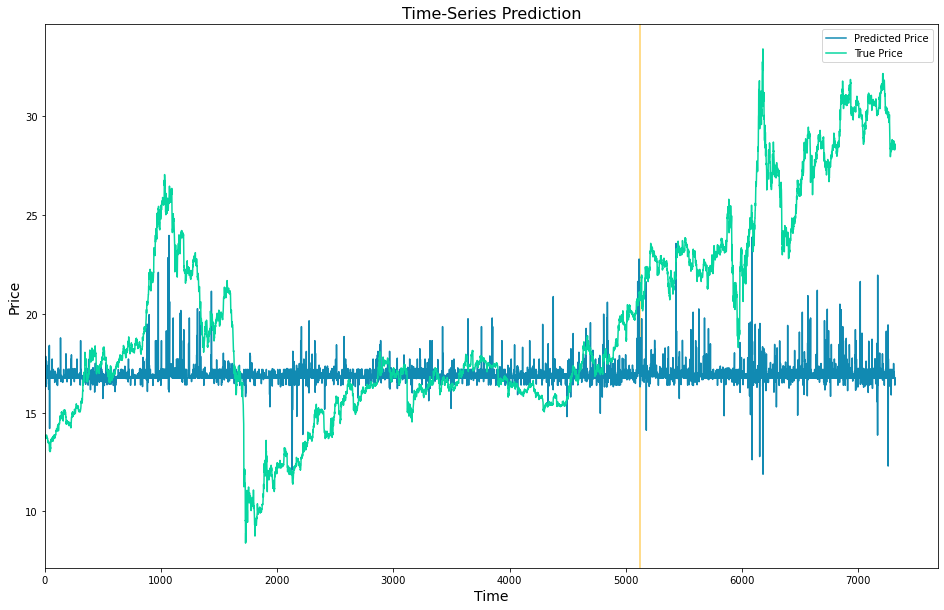

bitcoin-cashhourly.csv
Epoch: 0, loss: 0.69373
Epoch: 100, loss: 0.03460
Epoch: 200, loss: 0.03444
Epoch: 300, loss: 0.03436
Epoch: 400, loss: 0.03430
Epoch: 500, loss: 0.03426
Epoch: 600, loss: 0.03422
Epoch: 700, loss: 0.03420
Epoch: 800, loss: 0.03417
Epoch: 900, loss: 0.03415
% positive:  0.4949908925318761
% negative:  0.5050091074681239
% neutral:  0.0
positive correct:  0.5124195032198712
negative correct:  0.5464382326420198
neutral prediction:  0.0
0.5295992714025501


<Figure size 432x288 with 0 Axes>

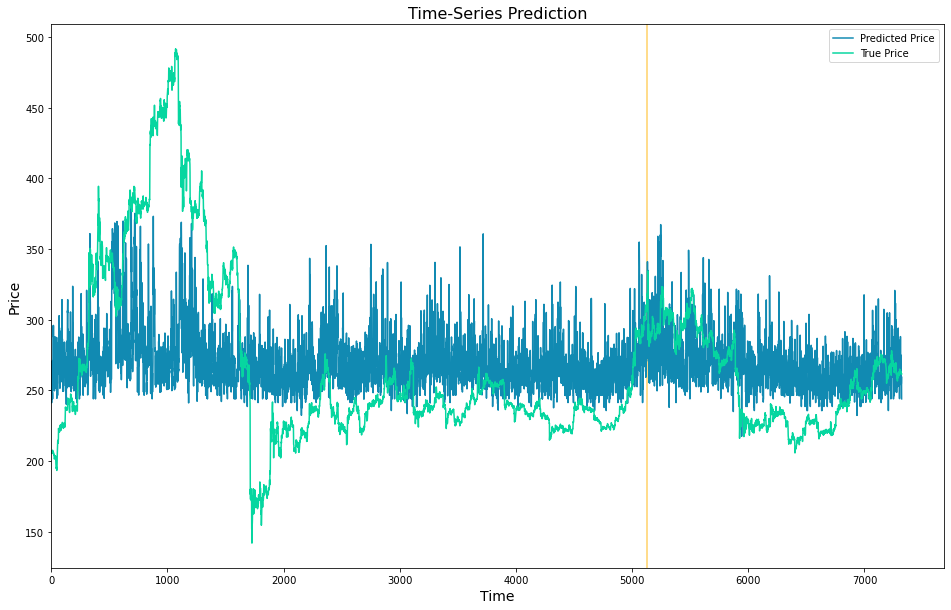

bitcoinhourly.csv
Epoch: 0, loss: 0.56835
Epoch: 100, loss: 0.01720
Epoch: 200, loss: 0.01669
Epoch: 300, loss: 0.01656
Epoch: 400, loss: 0.01649
Epoch: 500, loss: 0.01645
Epoch: 600, loss: 0.01642
Epoch: 700, loss: 0.01639
Epoch: 800, loss: 0.01637
Epoch: 900, loss: 0.01635
% positive:  0.5150273224043715
% negative:  0.4849726775956284
% neutral:  0.0
positive correct:  0.5287356321839081
negative correct:  0.5183098591549296
neutral prediction:  0.0
0.52367941712204


<Figure size 432x288 with 0 Axes>

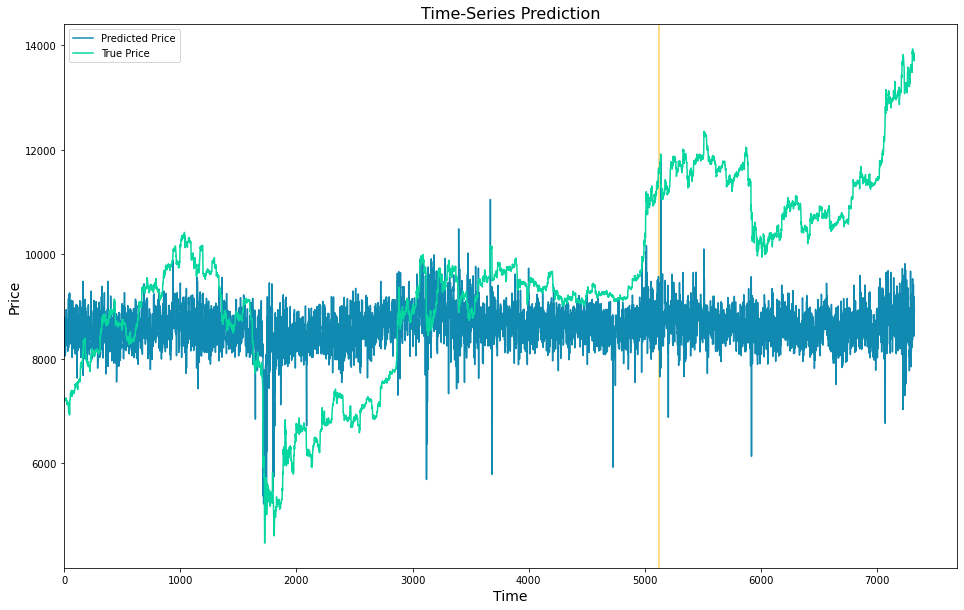

cardanohourly.csv
Epoch: 0, loss: 0.46866
Epoch: 100, loss: 0.03731
Epoch: 200, loss: 0.03635
Epoch: 300, loss: 0.03616
Epoch: 400, loss: 0.03606
Epoch: 500, loss: 0.03599
Epoch: 600, loss: 0.03592
Epoch: 700, loss: 0.03587
Epoch: 800, loss: 0.03583
Epoch: 900, loss: 0.03579
% positive:  0.49271402550091076
% negative:  0.5072859744990893
% neutral:  0.0
positive correct:  0.5092421441774492
negative correct:  0.5089766606822262
neutral prediction:  0.0
0.5091074681238615


<Figure size 432x288 with 0 Axes>

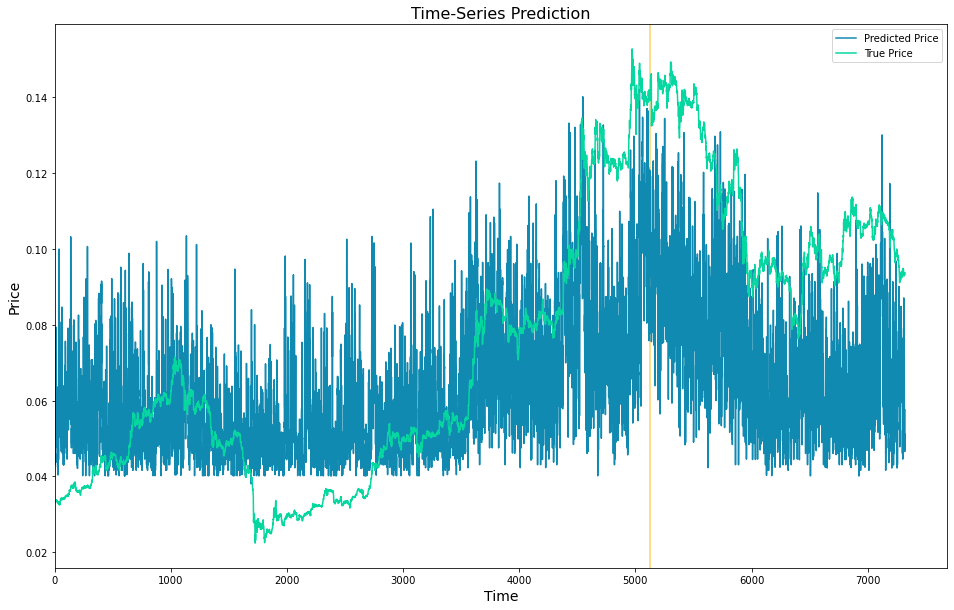

chainlinkhourly.csv
Epoch: 0, loss: 0.12180
Epoch: 100, loss: 0.00610
Epoch: 200, loss: 0.00596
Epoch: 300, loss: 0.00594
Epoch: 400, loss: 0.00592
Epoch: 500, loss: 0.00592
Epoch: 600, loss: 0.00591
Epoch: 700, loss: 0.00591
Epoch: 800, loss: 0.00590
Epoch: 900, loss: 0.00589
% positive:  0.4840619307832423
% negative:  0.5159380692167578
% neutral:  0.0
positive correct:  0.44402634054562556
negative correct:  0.5913503971756399
neutral prediction:  0.0
0.5200364298724954


<Figure size 432x288 with 0 Axes>

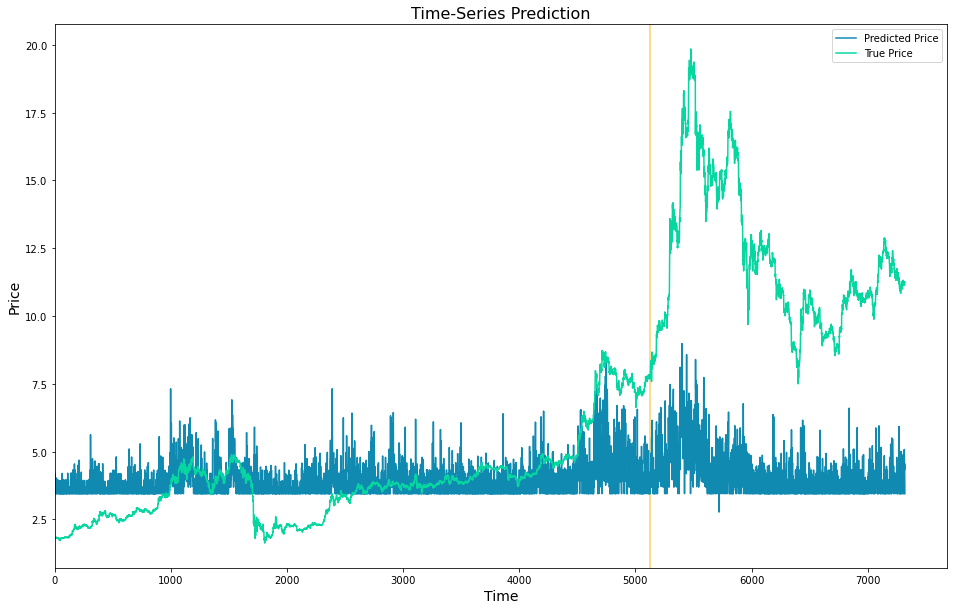

ethereumhourly.csv
Epoch: 0, loss: 0.11922
Epoch: 100, loss: 0.01223
Epoch: 200, loss: 0.01201
Epoch: 300, loss: 0.01190
Epoch: 400, loss: 0.01185
Epoch: 500, loss: 0.01182
Epoch: 600, loss: 0.01181
Epoch: 700, loss: 0.01180
Epoch: 800, loss: 0.01179
Epoch: 900, loss: 0.01178
% positive:  0.5086520947176685
% negative:  0.4913479052823315
% neutral:  0.0
positive correct:  0.5031333930170099
negative correct:  0.5152919369786839
neutral prediction:  0.0
0.5091074681238615


<Figure size 432x288 with 0 Axes>

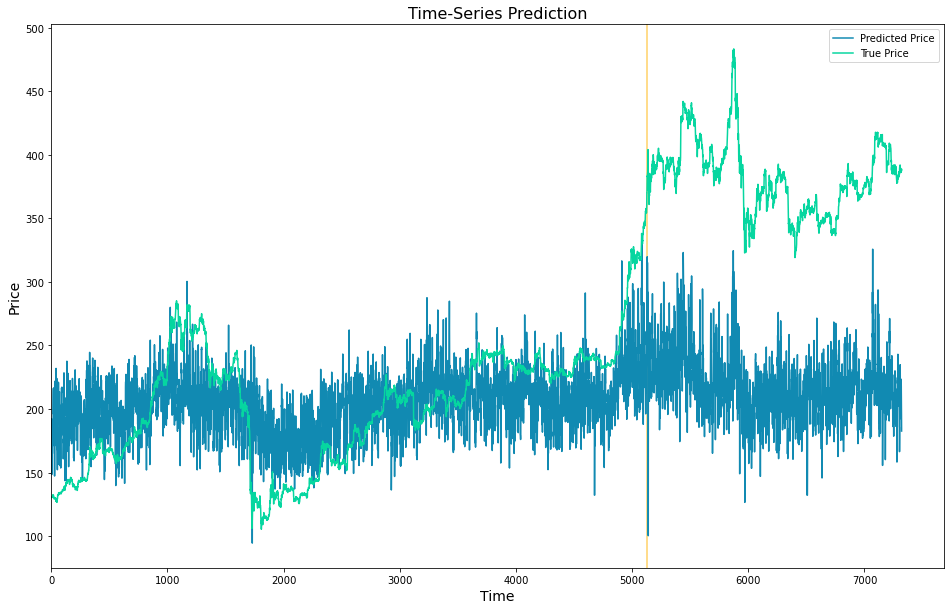

litecoinhourly.csv
Epoch: 0, loss: 0.11507
Epoch: 100, loss: 0.03989
Epoch: 200, loss: 0.03979
Epoch: 300, loss: 0.03974
Epoch: 400, loss: 0.03966
Epoch: 500, loss: 0.03958
Epoch: 600, loss: 0.03952
Epoch: 700, loss: 0.03947
Epoch: 800, loss: 0.03941
Epoch: 900, loss: 0.03935
% positive:  0.49089253187613846
% negative:  0.5091074681238615
% neutral:  0.0
positive correct:  0.47959183673469385
negative correct:  0.5420393559928444
neutral prediction:  0.0
0.511384335154827


<Figure size 432x288 with 0 Axes>

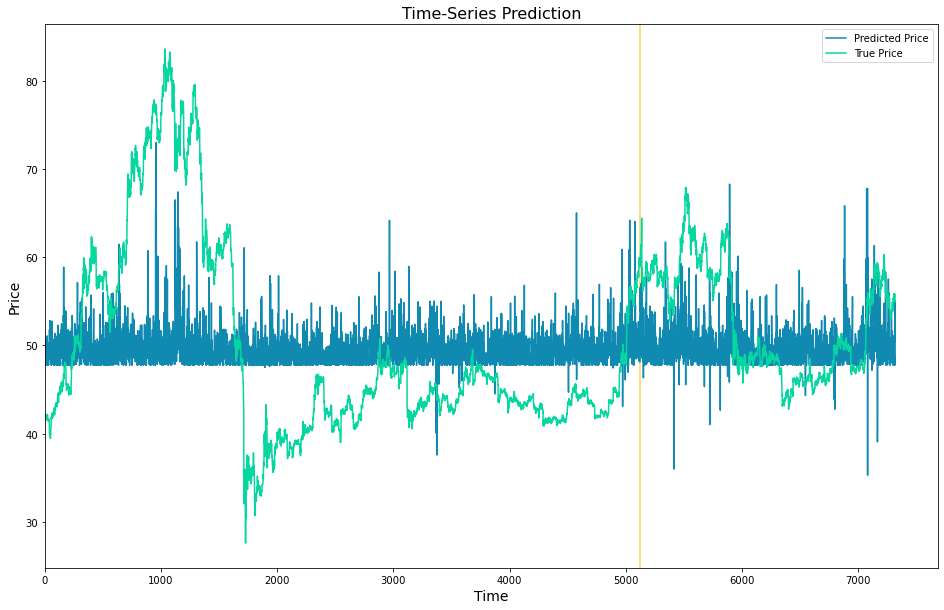

ripplehourly.csv
Epoch: 0, loss: 0.05157
Epoch: 100, loss: 0.02494
Epoch: 200, loss: 0.02483
Epoch: 300, loss: 0.02478
Epoch: 400, loss: 0.02472
Epoch: 500, loss: 0.02464
Epoch: 600, loss: 0.02452
Epoch: 700, loss: 0.02441
Epoch: 800, loss: 0.02432
Epoch: 900, loss: 0.02423
% positive:  0.4936247723132969
% negative:  0.5063752276867031
% neutral:  0.0
positive correct:  0.5092250922509225
negative correct:  0.52068345323741
neutral prediction:  0.0
0.5150273224043715


<Figure size 432x288 with 0 Axes>

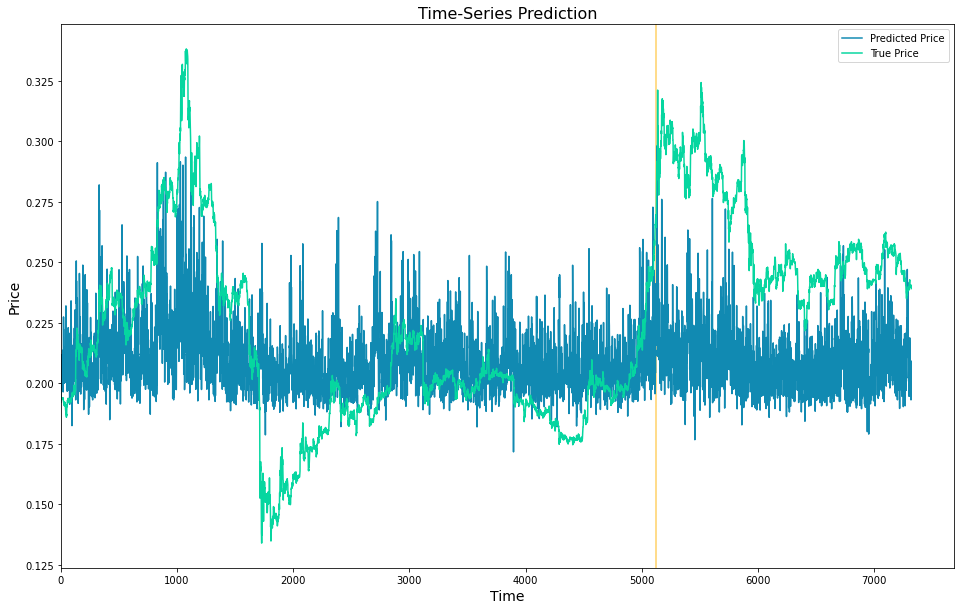

stellarhourly.csv
Epoch: 0, loss: 0.65908
Epoch: 100, loss: 0.04026
Epoch: 200, loss: 0.03501
Epoch: 300, loss: 0.03402
Epoch: 400, loss: 0.03396
Epoch: 500, loss: 0.03393
Epoch: 600, loss: 0.03389
Epoch: 700, loss: 0.03384
Epoch: 800, loss: 0.03381
Epoch: 900, loss: 0.03377
% positive:  0.5036429872495446
% negative:  0.49635701275045535
% neutral:  0.0
positive correct:  0.4204339963833635
negative correct:  0.5889908256880734
neutral prediction:  0.0
0.5040983606557377


<Figure size 432x288 with 0 Axes>

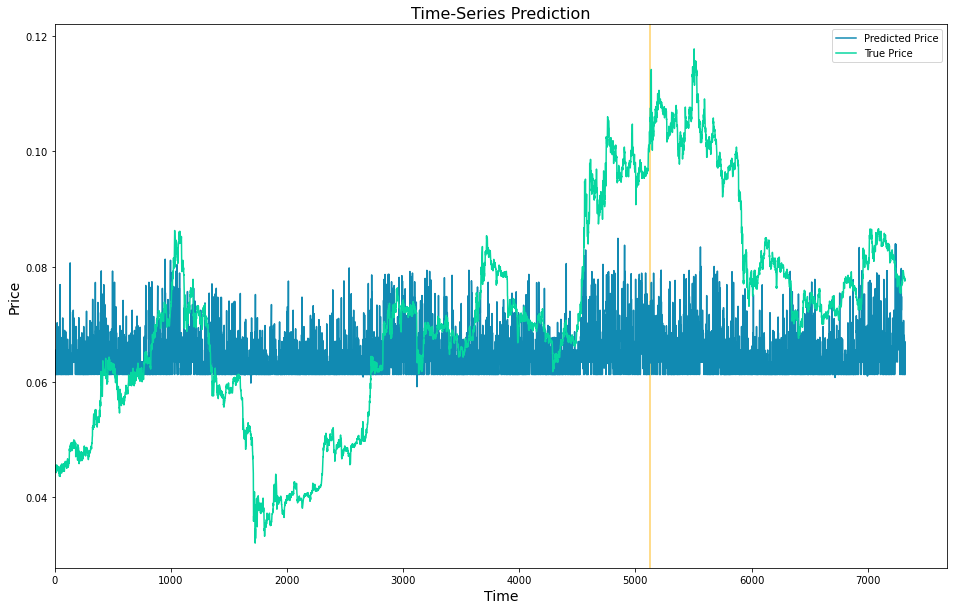

<Figure size 432x288 with 0 Axes>

In [13]:
dir_path = "datatest/"
file_list = [f for f in listdir(dir_path) if isfile(join(dir_path, f))]
#file_list = [f for f in listdir() if isfile(f)]

file_endings = ["5m.csv", "hourly.csv", "daily.csv"]

# FIXME: move to each fileending?
# im going to start with just 5m
file_ending = file_endings[1]
results = []
for filename in [name for name in file_list if file_ending in name]:
  crypto_name = filename.replace(file_ending, "")
  print(filename)
  
  df = pd.read_csv(dir_path + filename)
  # remove unused columns
  exclude_cols = [1]
  df = df.iloc[:, ~df.columns.isin(df.columns[exclude_cols])]

  # define LSTM class
  lstm = LSTMCustom(num_classes, input_size, hidden_size, num_layers, df.shape[1]) 
  optimizer = torch.optim.Adam(lstm.parameters(), lr=learning_rate) 

  lstm, cutoff = train(df, lstm)

  df_x_ss = ss.transform(df.iloc[:, 1:-2]) #old transformers
  df_y_mm = mm.transform(df.iloc[:, -1:]) #old transformers

  df_x_ss = Variable(torch.Tensor(df_x_ss)) #converting to Tensors
  df_y_mm = Variable(torch.Tensor(df_y_mm))
  #reshaping the dataset
  df_x_ss = torch.reshape(df_x_ss, (df_x_ss.shape[0], 1, df_x_ss.shape[1]))

  train_predict = lstm(df_x_ss) #forward pass
  data_predict = train_predict.data.numpy() #numpy conversion
  
  dataY_plot = df_y_mm.data.numpy()

  data_predict = mm.inverse_transform(data_predict) #reverse transformation
  #print(df.iloc[cutoff:].priceDirection.reset_index(drop=True))

  accuracy = classify(data_predict[cutoff:], df.iloc[cutoff:].priceDirection.reset_index(drop=True))
  print(accuracy)
  dataY_plot = mm.inverse_transform(dataY_plot)

  plot_name = f"{crypto_name}.png"
  plot_time_series(data_predict, dataY_plot, cutoff, plot_name)

  #model_name = f"{crypto_name}.pth"
  #torch.save(lstm.state_dict(), model_name)

  results.append([filename, num_epochs, learning_rate, accuracy])

In [14]:
print(results)

[['binance-coinhourly.csv', 1000, 0.01, 0.5127504553734062], ['bitcoin-cashhourly.csv', 1000, 0.01, 0.5295992714025501], ['bitcoinhourly.csv', 1000, 0.01, 0.52367941712204], ['cardanohourly.csv', 1000, 0.01, 0.5091074681238615], ['chainlinkhourly.csv', 1000, 0.01, 0.5200364298724954], ['ethereumhourly.csv', 1000, 0.01, 0.5091074681238615], ['litecoinhourly.csv', 1000, 0.01, 0.511384335154827], ['ripplehourly.csv', 1000, 0.01, 0.5150273224043715], ['stellarhourly.csv', 1000, 0.01, 0.5040983606557377]]


In [15]:
resultsdf = pd.DataFrame(results)

In [16]:
print(resultsdf)

                        0     1     2         3
0  binance-coinhourly.csv  1000  0.01  0.512750
1  bitcoin-cashhourly.csv  1000  0.01  0.529599
2       bitcoinhourly.csv  1000  0.01  0.523679
3       cardanohourly.csv  1000  0.01  0.509107
4     chainlinkhourly.csv  1000  0.01  0.520036
5      ethereumhourly.csv  1000  0.01  0.509107
6      litecoinhourly.csv  1000  0.01  0.511384
7        ripplehourly.csv  1000  0.01  0.515027
8       stellarhourly.csv  1000  0.01  0.504098
